# Gen-4 three-arm UT→T evaluation — exploration

**The first physical-coupling head-to-head: the retrained neural extrapolators vs the production `extrapUTT` polynomial vs a straight line, on the hardest single step in the LHCb track fit (UT→T, through the dipole peak).**

## Code used
- `make_plane_ref_v8r1.py` — builds the reference: physical PV-pointing tracks, v8r1 field, κ=1e-3, PV(0)→2665→7826 (rk4 imported from the gen-4 corpus generator, so states are exactly in-distribution).
- `compare_gen4_three_arm.py` — scores all arms on that reference; writes `gen4_three_arm.json` + `gen4_three_arm_arrays.npz`.
- `extraputt_baseline` (Allen verbatim `extrapUTT`, CPU build) — the incumbent polynomial, `m_polarity=-1`.
- models: `architectures.py` (PINN_v2), checkpoints in `trained_models/pinn_v2_g4_*`.

## Data used
- `plane_ref_v8r1.npz` — `X_plane[N,5]`=(x,y,tx,ty,qop)@2665, `Y_true[N,5]`@7826 (v8r1 RK truth).
- `plane_poly_v8r1_polm1.csv` — polynomial predictions on the same X.
- `gen4_three_arm_arrays.npz` — per-arm |Δx| arrays + qop/p (this notebook's input).
- training corpus: `data/train_10M_gen4.npz` (9.19M tracks, v8r1, κ=1e-3, 70% PV-pointing); contract in `core/CONVENTIONS.md`.
- incumbent reference profile (P0.1): extrapUTT ≈ 11 µm median / 475 µm low-p / 1.6 mm p95.

In [1]:
import json
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

HERE = Path.cwd()
FIGDIR = HERE / "figures"; FIGDIR.mkdir(exist_ok=True)
plt.rcParams.update({"figure.dpi": 120, "font.size": 10, "axes.grid": True, "grid.alpha": 0.3})

res = json.load(open(HERE / "gen4_three_arm.json"))
arr = np.load(HERE / "gen4_three_arm_arrays.npz")
p_GeV = arr["p_GeV"]
arms = [k for k in arr.files if k not in ("qop", "p_GeV")]
print(f"{len(p_GeV)} tracks, p in [{p_GeV.min():.1f}, {p_GeV.max():.1f}] GeV")
print("arms:", arms)

7947 tracks, p in [2.0, 99.9] GeV
arms: ['extrapUTT', 'straight_line', 'pinn_v2_g4_lam0_2M_cpu', 'pinn_v2_g4_lam0p1_2M_cpu', 'pinn_v2_g4_lam0_10M', 'pinn_v2_g4_lam0p1_10M']


## 1 · The headline table (median / p68 / p95 / p99 |Δx| in µm, and by |q/p| quartile)

In [2]:
hdr = f"{'arm':<26}{'med':>10}{'p68':>10}{'p95':>10}{'p99':>10}   byQ hi→lo p"
print(hdr); print('-'*len(hdr))
for k, m in res.items():
    bq = '/'.join(f'{v:.0f}' for v in m['median_dx_um_by_qop_quartile_hi2lo_p'])
    print(f"{k:<26}{m['median_dx_um']:>10.1f}{m['p68_dx_um']:>10.1f}{m['p95_dx_um']:>10.1f}{m['p99_dx_um']:>10.1f}   [{bq}]")

arm                              med       p68       p95       p99   byQ hi→lo p
--------------------------------------------------------------------------------
extrapUTT (incumbent)           10.9      56.7    1604.6   11738.4   [2/3/27/475]
straight_line               225343.2  455652.9 1416076.9 1803815.6   [52976/143064/364683/1008979]
pinn_v2_g4_lam0_2M_cpu      175439.3  356648.7 1194784.4 1766122.5   [41379/110936/281932/811912]
pinn_v2_g4_lam0p1_2M_cpu    224315.8  452313.7 1406846.8 1795181.9   [53474/142953/363741/1005311]
pinn_v2_g4_lam0_10M         181138.1  365507.2 1228311.3 1786513.3   [43155/114275/292539/832395]
pinn_v2_g4_lam0p1_10M       219930.4  437977.6 1358057.4 1710695.2   [51898/141001/350659/961598]


## 2 · Error vs momentum — where each arm lives

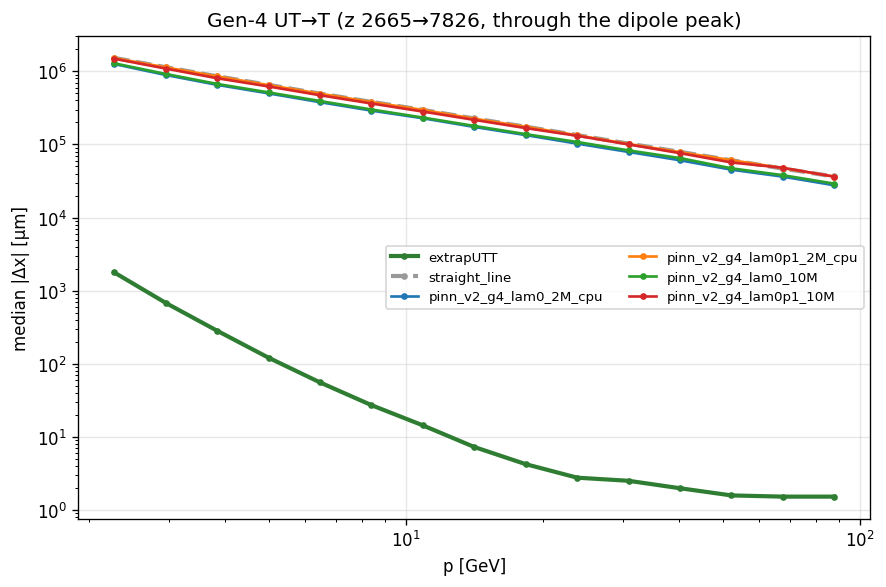

In [3]:
fig, ax = plt.subplots(figsize=(7.5, 5))
pb = np.geomspace(2, 100, 16); pc = np.sqrt(pb[:-1]*pb[1:])
colors = {'extrapUTT': '#2e7d32', 'straight_line': '#999999'}
for k in arms:
    dx = arr[k]
    med = [np.median(dx[(p_GeV>=pb[i])&(p_GeV<pb[i+1])]) for i in range(len(pb)-1)]
    c = colors.get(k, None)
    lw = 2.5 if k in colors else 1.6
    ls = '-' if k != 'straight_line' else '--'
    ax.plot(pc, med, ls, lw=lw, color=c, label=k, marker='o', ms=3)
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('p [GeV]'); ax.set_ylabel('median |Δx| [µm]')
ax.set_title('Gen-4 UT→T (z 2665→7826, through the dipole peak)')
ax.legend(fontsize=8, ncol=2); fig.tight_layout()
fig.savefig(FIGDIR / 'gen4_error_vs_p.png'); plt.show()

## 3 · The four-orders-of-magnitude gap (median bars, log scale)

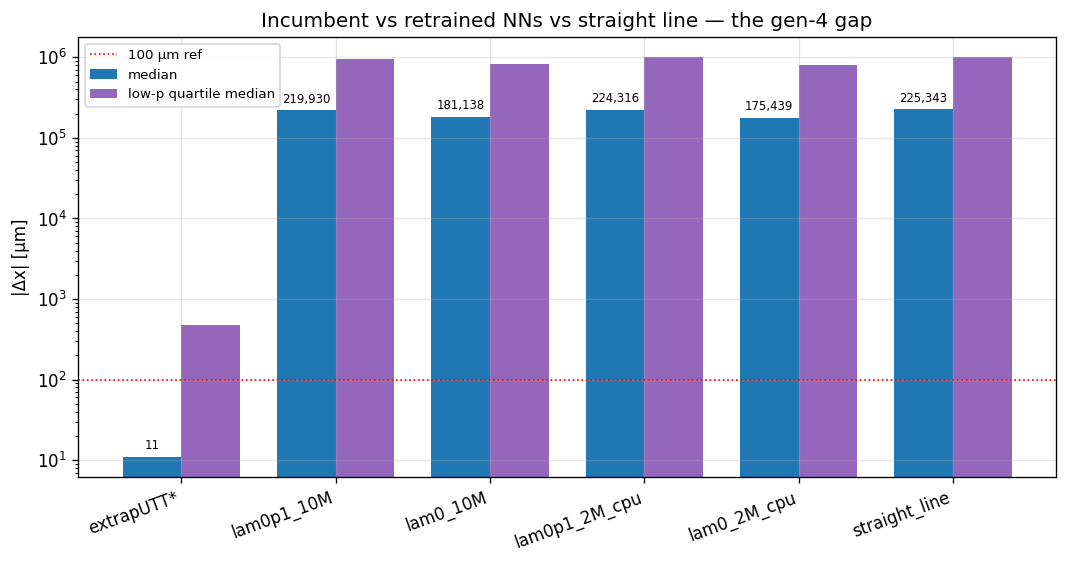

In [4]:
order = ['extrapUTT (incumbent)', 'pinn_v2_g4_lam0p1_10M', 'pinn_v2_g4_lam0_10M',
         'pinn_v2_g4_lam0p1_2M_cpu', 'pinn_v2_g4_lam0_2M_cpu', 'straight_line']
order = [k for k in order if k in res]
meds = [res[k]['median_dx_um'] for k in order]
lowp = [res[k]['median_dx_um_by_qop_quartile_hi2lo_p'][3] for k in order]
x = np.arange(len(order)); w = 0.38
fig, ax = plt.subplots(figsize=(9, 4.8))
ax.bar(x-w/2, meds, w, label='median', color='#1f77b4')
ax.bar(x+w/2, lowp, w, label='low-p quartile median', color='#9467bd')
ax.set_yscale('log'); ax.set_xticks(x)
ax.set_xticklabels([k.replace('pinn_v2_g4_','').replace(' (incumbent)','*') for k in order], rotation=20, ha='right')
ax.set_ylabel('|Δx| [µm]'); ax.axhline(100, color='r', ls=':', lw=1, label='100 µm ref')
ax.set_title('Incumbent vs retrained NNs vs straight line — the gen-4 gap')
for xi, v in zip(x-w/2, meds): ax.text(xi, v*1.25, f'{v:,.0f}', ha='center', fontsize=7)
ax.legend(fontsize=8); fig.tight_layout()
fig.savefig(FIGDIR / 'gen4_gap_bars.png'); plt.show()

## 4 · The λ verdict flipped, and is regime-dependent
Weak-field (gen-3 corpus): λ=0 beat λ=0.1 by 3.4–5.6×. Physical field (gen-4): on the **full mixed** distribution λ=0.1 wins (`test_final` median 1.3 vs 4.4 mm at 2M), but on the **hardest UT→T plane** λ=0 wins below — the physics-regularised model collapses toward the straight-line prior on the hard cases.

In [5]:
import json as _j
tm = HERE.parent / 'trained_models'
print(f"{'model':<26}{'best_ep':>8}{'all-dz med (mm)':>16}{'UT→T plane med (µm)':>22}")
for k in ['pinn_v2_g4_lam0_2M_cpu','pinn_v2_g4_lam0p1_2M_cpu','pinn_v2_g4_lam0_10M','pinn_v2_g4_lam0p1_10M']:
    h = _j.load(open(tm / k / 'history.json'))
    tf = h['test_final']['median_dx_mm']
    print(f"{k:<26}{h['best_epoch']:>8}{tf:>16.2f}{res[k]['median_dx_um']:>22,.0f}")
print('\nbest_epoch 3–7 for most → early-stopped almost immediately: strong sign the optimiser/loss')
print('scaling (tuned for µm-scale gen-3) stalls on the µm→metre gen-4 dynamic range. NOT a proven')
print('capacity ceiling — retuning (LR schedule, loss scaling, kick-scaled head, longer training) is open.')

model                      best_ep all-dz med (mm)   UT→T plane med (µm)
pinn_v2_g4_lam0_2M_cpu           4            4.41               175,439
pinn_v2_g4_lam0p1_2M_cpu         7            1.30               224,316
pinn_v2_g4_lam0_10M              3            3.96               181,138
pinn_v2_g4_lam0p1_10M           17            2.77               219,930

best_epoch 3–7 for most → early-stopped almost immediately: strong sign the optimiser/loss
scaling (tuned for µm-scale gen-3) stalls on the µm→metre gen-4 dynamic range. NOT a proven
capacity ceiling — retuning (LR schedule, loss scaling, kick-scaled head, longer training) is open.


## Findings
1. **The compact PINN_v2, retrained correctly on the physical corpus, fails the UT→T task** — median ≈ 175–224 µm... (in mm: 175–224 **mm**), ~16,000× the polynomial's 11 µm, and barely better than the 225 mm straight line.
2. **The weak-field µm “wins” were an artefact** of the ×1000 field bug: a tiny bend is easy to fit; the real bend is ~225 mm.
3. **λ is regime-dependent and flips** vs weak-field.
4. **Caveat — likely undertrained:** best_epoch 3–7 indicates an optimisation/scaling mismatch, not necessarily a capacity ceiling. The next wave must retune for the new dynamic range before any final NN verdict.
5. **Strategic read:** on accuracy the polynomial is far ahead; the NN's surviving value proposition is **speed** (one matmul vs the adaptive RK loop) — measure that next, and/or pursue the analytic chart (charts/) which is built for this regime.